# mCH vs gene expression correlation (Fig 3I, S23B)

For the major types with matched pseudobulk RNA, we correlate **gene-body mCH** with
**gene expression** across subtypes. **Fig 3I** shows, per major type, the distribution of
that correlation across genes (one violin per major type). **Fig S23B** shows how the
correlation-across-genes depends on **distance to the TSS** (per-subtype dots at ±1–10 kb
flanks plus the gene body).

Source: `analysis/mCH_geneexpr/{L1}/step3.mCH_geneexpr.ipynb` (one notebook per major type).
Here we load the per-type correlation arrays those notebooks write and assemble the two
published panels (the cross-major-type violin assembly was done ad hoc and is reconstructed here).

## 📥 Required input files

- `{ENTEX_ROOT}/L1color.tsv` · _major-type color/annotation_
- `{ENTEX_ROOT}/analysis/mCH_geneexpr/{L1}/corr_cross_ct_genebody.npy` · _per-gene mCH↔expr corr across subtypes (Fig 3I)_
- `{ENTEX_ROOT}/analysis/mCH_geneexpr/{L1}/corr_cross_gene.npy`, `corr_cross_gene_genebody.npy` · _corr across genes at each TSS-flank distance (Fig S23B)_

The per-type arrays are produced upstream in `mCH_geneexpr/{L1}/step3.mCH_geneexpr.ipynb`
from `subtype_geneCH.hdf` (gene-body mCH), `bulkexpr_*.hdf` (pseudobulk RNA), and the
subtype `allc` TSS-flank profiles.

In [1]:
import os, sys

ENTEX_ROOT = os.environ.get("ENTEX_ROOT", "/large_storage/zhoulab/zhoujt/project/ENTEx")

BOOK_ROOT = os.environ.get("BOOK_ROOT", f"{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas")

os.chdir(f"{ENTEX_ROOT}/analysis")

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
geneexpr_dir = f"{ENTEX_ROOT}/analysis/mCH_geneexpr/"

L1_meta = pd.read_csv(f"{ENTEX_ROOT}/L1color.tsv", sep="\t", header=0, index_col=0)

ct_list = ["c0", "c5", "c10", "c13", "c16", "c27"]

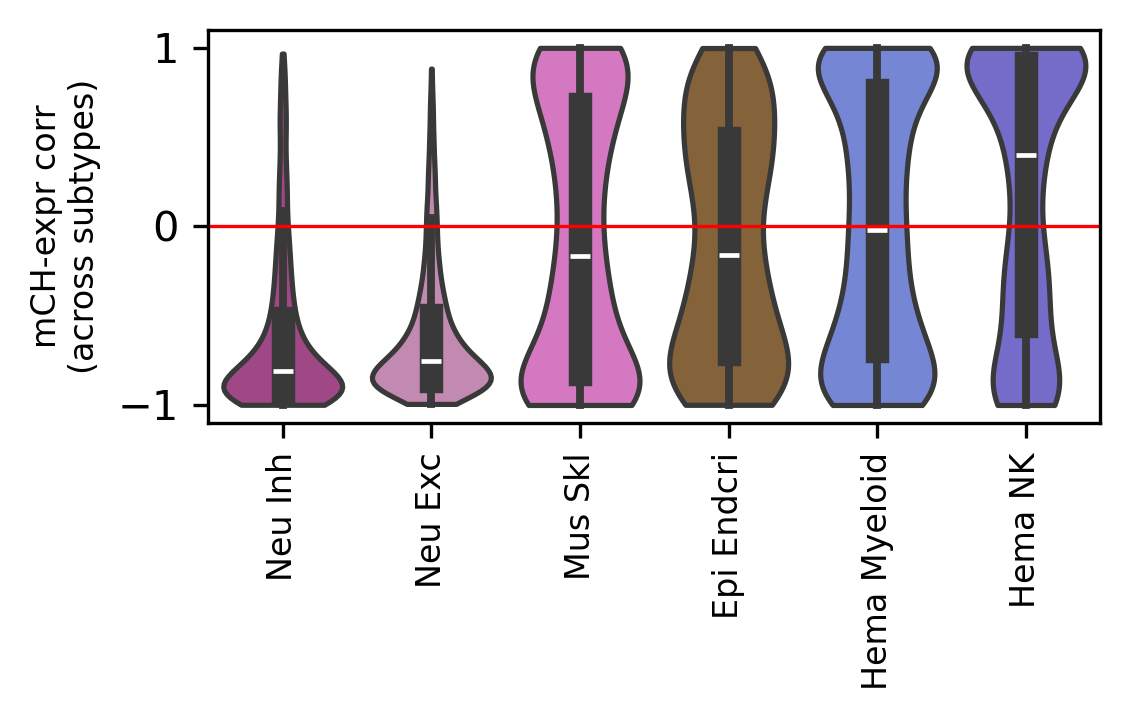

In [4]:
corr_by_l1 = {}

for ct in ct_list:
    f = f"{geneexpr_dir}{ct}/corr_cross_ct_genebody.npy"
    if os.path.exists(f):
        corr_by_l1[ct] = np.load(f)

order = sorted(corr_by_l1, key=lambda k: np.median(corr_by_l1[k]))

fig, ax = plt.subplots(figsize=(4, 2.5), dpi=300)

sns.violinplot(
    data=[corr_by_l1[k] for k in order],
    ax=ax,
    palette=[L1_meta.loc[k, "color"] for k in order],
    cut=0,
    inner="box",
)

ax.axhline(0, color="r", lw=0.8)

ax.set_xticks(np.arange(len(order)))

ax.set_xticklabels(L1_meta.loc[order, "L1_abbr"], rotation=90, fontsize=8)

ax.set_ylabel("mCH-expr corr\n(across subtypes)", fontsize=8)

fig.tight_layout()

fig.savefig("mCH_geneexpr/mCH_expr_corr_across_subtypes_violin.pdf", transparent=True)

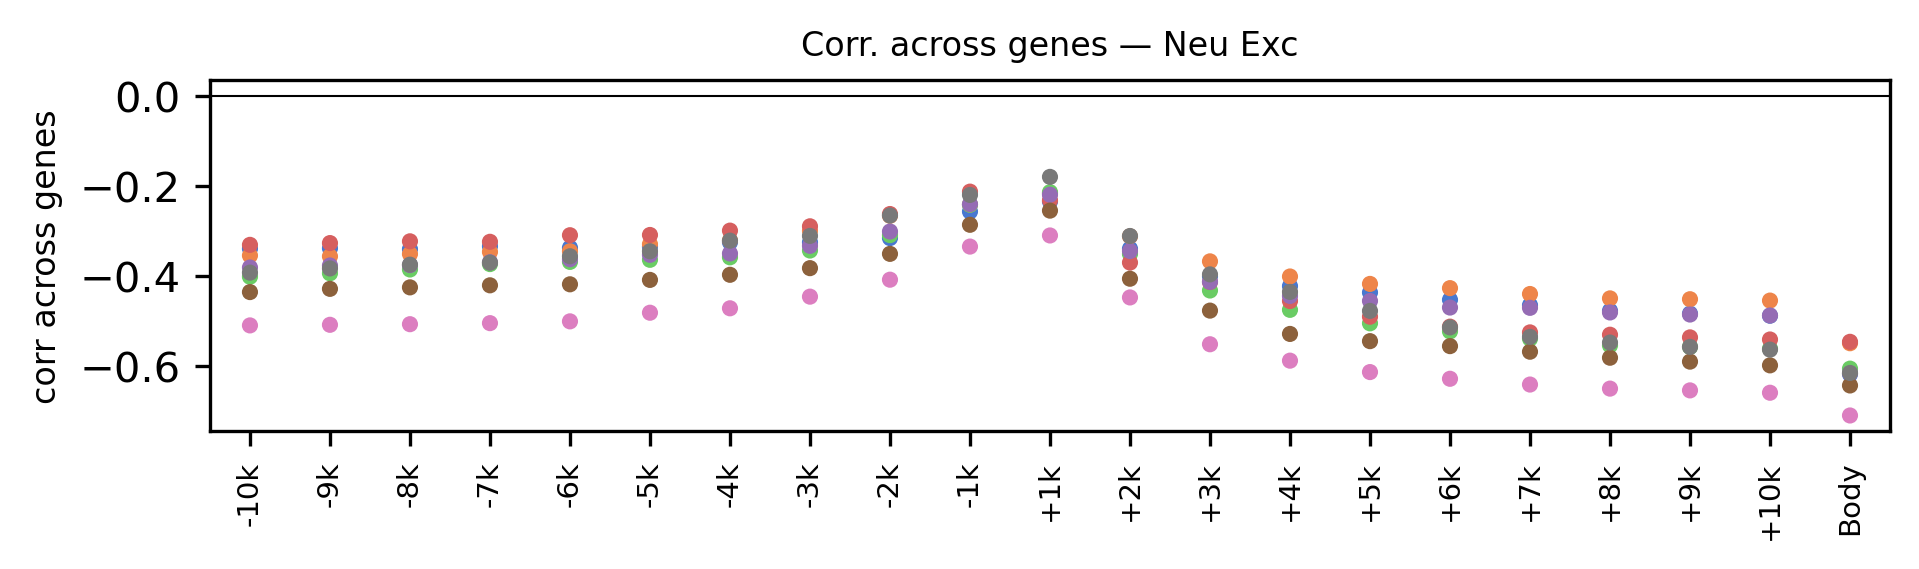

In [5]:
rep = "c10"

cross_gene = np.load(f"{geneexpr_dir}{rep}/corr_cross_gene.npy")

cross_gene_gb = np.load(f"{geneexpr_dir}{rep}/corr_cross_gene_genebody.npy")

cross_gene = np.concatenate([cross_gene, cross_gene_gb[None, :]], axis=0)

n_sub = cross_gene.shape[1]

palette = sns.color_palette("muted", n_sub)

fig, ax = plt.subplots(figsize=(6.5, 2), dpi=300)

ax.scatter(
    np.repeat(np.arange(21), n_sub),
    cross_gene.flatten(),
    c=np.tile(palette, (21, 1)),
    s=15,
    edgecolor="none",
    rasterized=True,
)

ax.axhline(0, color="k", lw=0.5)

ax.set_title(f'Corr. across genes — {L1_meta.loc[rep, "L1_abbr"]}', fontsize=8)

ax.set_xticks(np.arange(21))

ticklabels = (
    [f"-{x}k" for x in np.arange(1, 11)][::-1] + [f"+{x}k" for x in np.arange(1, 11)] + ["Body"]
)

ax.set_xticklabels(ticklabels, rotation=90, fontsize=7)

ax.set_xlim([-0.5, 20.5])

ax.set_ylabel("corr across genes", fontsize=8)

fig.tight_layout()

fig.savefig("mCH_geneexpr/mCH_expr_corr_across_genes_TSS.pdf", transparent=True)